In [1]:
%%capture
import re
import pandas as pd 
import numpy as np
from pathlib import Path
from importlib import reload
import matplotlib.pyplot as plt
from convokit import Corpus, download

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
if torch.cuda.is_available():
    device = "cuda"

torch.cuda.is_available()

corpus = Corpus(download('news-interview'))

# Data generation

In [2]:
dir = Path('../data/transcripts')
doc_paths = sorted(dir.glob('*.txt'))

In [3]:
df = corpus.get_conversations_dataframe()
df.keys()

Index(['vectors', 'meta.title', 'meta.summary', 'meta.program', 'meta.date',
       'meta.url', 'meta.info_items', 'meta.outlines', 'meta.info_items_dict'],
      dtype='str')

In [5]:
from utils.utils import parse_transcript
lines = parse_transcript(
    doc_paths[0],
    speakers = ["JO LING KENT", "DARIO AMODEI"]
)

In [6]:
import math
from collections import Counter

excerpts = []
window_size = 20

for n in range(len(lines) - 20 + 1):
    segment = lines[n: n + window_size]
    
    current_speaker = ''
    baseline_text = ''
    turns = []
    for l in segment:
        if current_speaker != l['turn_speaker']:
            current_speaker = l['turn_speaker']
            baseline_text += l['turn_speaker']+ ': ' + l['line_text'] + '\n'
        else:
            baseline_text += l['line_text'] + '\n'
    
    min_turn = segment[0]['turn_id']
    max_turn = segment[-1]['turn_id']


    e_dict = {
        'source': f'{n}:{n+window_size}',
        'lines': segment,
        'speakers': set([l['turn_speaker'] for l in segment]),
        'speaker_line_count': dict(Counter(l['turn_speaker'] for l in segment)),
        'baseline_text': baseline_text,
        'unlabeled_text': ''.join([f"{l['line_text']}\n" for l in segment]),
        #'corrupted_labels': a case where the labels are mis-attributed and the model needs to "repair" it
        'num_turns': max_turn - min_turn
        }

    excerpts.append(e_dict)

excerpts

[{'source': '0:20',
  'lines': [{'line_id': 1,
    'turn_id': 1,
    'turn_speaker': 'JO LING KENT',
    'line_text': 'All right. Thank you for doing this with us today.'},
   {'line_id': 2,
    'turn_id': 2,
    'turn_speaker': 'DARIO AMODEI',
    'line_text': 'Thank-- thanks for having me.'},
   {'line_id': 3,
    'turn_id': 3,
    'turn_speaker': 'JO LING KENT',
    'line_text': 'We appreciate you taking the time. You are Dario Amodei, the CEO of Anthropic. Is that right?'},
   {'line_id': 4,
    'turn_id': 4,
    'turn_speaker': 'DARIO AMODEI',
    'line_text': "That's correct, yes."},
   {'line_id': 5,
    'turn_id': 5,
    'turn_speaker': 'JO LING KENT',
    'line_text': "Great. Well, I-- my first question to you is why won't you release Anthropic's AI without restrictions to the U.S. government?"},
   {'line_id': 6,
    'turn_id': 6,
    'turn_speaker': 'DARIO AMODEI',
    'line_text': 'Yeah. So, you know, we should maybe back up a bit for a little bit of context. So, you know, 

# Eval 

In [ ]:
# speaker count: quick eval to see if the model can do this individuation task
import gc
import re
from textwrap import dedent

import pandas as pd
import torch
from nnsight import LanguageModel

models = [
    # Add/remove model IDs as needed.
    "allenai/Olmo-3-1125-32B",
]

num_eval_examples = min(10, len(excerpts))

def parse_first_int(text):
    match = re.search(r"\\b(\\d+)\\b", text)
    return int(match.group(1)) if match else None

results = []

for model_id in models:
    llm = LanguageModel(model_id, device_map="auto", remote=True)

    for e in excerpts[:num_eval_examples]:
        prompt = dedent(f"""\
        You will be asked how many speakers are involved in a conversation excerpt.
        Output only a single number as your final answer.

        Here is the excerpt:
        ```
        {e['unlabeled_text']}
        ```
        Output:
        """)

        response = ""
        error = None

        try:
            with llm.generate(
                prompt,
                max_new_tokens=64,
                temperature=0.0,
                do_sample=False,
                remote=True,
            ):
                generated = llm.generator.output.save()

            decoded = llm.tokenizer.decode(generated[0], skip_special_tokens=True)
            response = decoded[len(prompt):].strip() if decoded.startswith(prompt) else decoded.strip()
        except Exception as exc:
            error = str(exc)

        pred = parse_first_int(response)
        ground_truth = len(e["speakers"])

        results.append(
            {
                "model": model_id,
                "response": response,
                "predicted_speakers": pred,
                "ground_truth": ground_truth,
                "correct": pred == ground_truth,
                "error": error,
                "source": e["source"],
                "excerpt": e["unlabeled_text"],
            }
        )

    del llm
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

results_df = pd.DataFrame(results)
results_df


⬇ Downloading: 100%|██████████| 2.92k/2.92k [00:00<00:00]


⬇ Downloading: 100%|██████████| 2.94k/2.94k [00:00<00:00]


⬇ Downloading: 100%|██████████| 3.22k/3.22k [00:00<00:00]


⬇ Downloading: 100%|██████████| 3.20k/3.20k [00:00<00:00]


⬇ Downloading: 100%|██████████| 3.20k/3.20k [00:00<00:00]


...

⬇ Downloading: 100%|██████████| 3.13k/3.13k [00:00<00:00]


⬇ Downloading: 100%|██████████| 3.06k/3.06k [00:00<00:00]


⬇ Downloading: 100%|██████████| 2.95k/2.95k [00:00<00:00]


⬇ Downloading: 100%|██████████| 3.00k/3.00k [00:00<00:00]


⬇ Downloading: 100%|██████████| 2.96k/2.96k [00:00<00:00]


# Activations

In [51]:
from transformers import AutoTokenizer
from nnsight import LanguageModel
import re
from collections import defaultdict

speaker_re = re.compile(r"^([A-Z][A-Z '\-\.]+):\s*(.*)$")

def split_into_utterances(transcript_text):
    utterances = []
    current = None

    for raw_line in transcript_text.splitlines():
        line = raw_line.strip()
        if not line:
            continue

        m = speaker_re.match(line)
        if m:
            # start a new utterance
            speaker = m.group(1).strip()
            text = m.group(2).strip()

            current = {"speaker": speaker, "text": text}
            utterances.append(current)
        else:
            # continuation of previous speaker's utterance
            if current is not None:
                current["text"] += " " + line

    return utterances

def build_turn_spans(segment_lines, include_speaker_prefix=False):
    """
    Build character spans for each turn in baseline_text space.

    include_speaker_prefix=False means spans only cover spoken content,
    not the `SPEAKER: ` prefix tokens.
    """
    turn_spans = []
    current_speaker = ""
    cursor = 0

    for line in segment_lines:
        speaker = line["turn_speaker"]
        text = line["line_text"]

        if speaker != current_speaker:
            current_speaker = speaker
            prefix = f"{speaker}: "

            span_start = cursor if include_speaker_prefix else cursor + len(prefix)
            span_end = cursor + len(prefix) + len(text)

            turn_spans.append({
                "turn_id": line["turn_id"],
                "speaker": speaker,
                "start": span_start,
                "end": span_end,
            })
            cursor = span_end + 1  # newline
        else:
            span_end = cursor + len(text)
            turn_spans[-1]["end"] = span_end
            cursor = span_end + 1  # newline

    return turn_spans

def pool_tokens_by_turn(hidden_states, offsets, turn_spans):
    """Mean-pool token vectors into one vector per turn."""
    H = hidden_states.float().cpu()
    if len(offsets) != H.shape[0]:
        min_len = min(len(offsets), H.shape[0])
        offsets = offsets[:min_len]
        H = H[:min_len]

    buckets = defaultdict(list)
    span_idx = 0

    for tok_idx, (start, end) in enumerate(offsets):
        # Special tokens usually map to (0, 0); skip them.
        if end <= start:
            continue

        mid = 0.5 * (start + end)

        while span_idx < len(turn_spans) and mid >= turn_spans[span_idx]["end"]:
            span_idx += 1

        if span_idx < len(turn_spans):
            span = turn_spans[span_idx]
            if span["start"] <= mid < span["end"]:
                buckets[span["turn_id"]].append(H[tok_idx])

    pooled = []
    meta = []
    for span in turn_spans:
        turn_id = span["turn_id"]
        if turn_id in buckets and len(buckets[turn_id]) > 0:
            pooled.append(torch.stack(buckets[turn_id]).mean(dim=0))
            meta.append(span)

    if not pooled:
        raise ValueError("No tokens were assigned to turns. Check offset mapping / spans.")

    return torch.stack(pooled).numpy(), meta

In [23]:
excerpt_idx = 0
segment_lines = excerpts[excerpt_idx]["lines"]

baseline = excerpts[excerpt_idx]["baseline_text"]
unlabeled = excerpts[excerpt_idx]["unlabeled_text"]

# Split baseline into utterances (one item per contiguous speaker block).
utterances = split_into_utterances(baseline)

# Char spans used to pool token activations into one vector per turn.
# Set True if you want speaker-prefix tokens to contribute to pooling.
turn_spans = build_turn_spans(segment_lines, include_speaker_prefix=False)


In [40]:
# load models via nnsight
id = 'allenai/Olmo-3-1125-32B'
model = LanguageModel(id, device_map = 'auto', remote = 'true')
tokenizer = AutoTokenizer.from_pretrained(id)
# print(llm)

In [35]:
saved_states = None

with model.trace(baseline, remote=True):
    saved_states = dict().save()
    for i, layer in enumerate(model.model.layers):
        if i % 8 == 0:
            saved_states[i] = layer.output[0].save()

⬇ Downloading: 100%|██████████| 73.7M/73.7M [00:01<00:00]


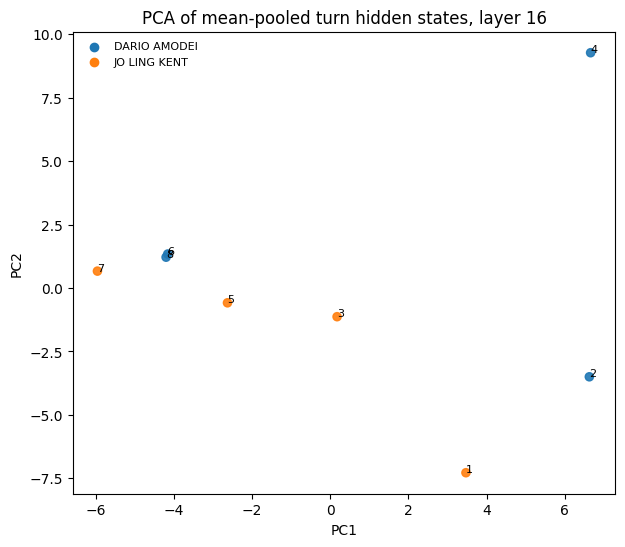

Explained variance ratio: [0.31880173 0.28065023]
Turns plotted: 8


In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

layer = 16
X_turn, turn_meta = pool_tokens_by_turn(saved_states[layer], offsets, turn_spans)

pca = PCA(n_components=2)
coords = pca.fit_transform(X_turn)

speakers = [m["speaker"] for m in turn_meta]
unique_speakers = sorted(set(speakers))
cmap = {sp: plt.cm.tab10(i % 10) for i, sp in enumerate(unique_speakers)}
colors = [cmap[sp] for sp in speakers]

plt.figure(figsize=(7, 6))
plt.scatter(coords[:, 0], coords[:, 1], c=colors, s=35, alpha=0.9)
for i, m in enumerate(turn_meta):
    plt.text(coords[i, 0], coords[i, 1], str(m["turn_id"]), fontsize=8)

for sp in unique_speakers:
    plt.scatter([], [], c=[cmap[sp]], label=sp)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"PCA of mean-pooled turn hidden states, layer {layer}")
plt.legend(loc="best", fontsize=8, frameon=False)
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Turns plotted:", len(turn_meta))

In [ ]:
enc = model.tokenizer(
    baseline,
    return_offsets_mapping=True,
    return_tensors="pt",
)

input_ids = enc["input_ids"][0]
offsets = enc["offset_mapping"][0].tolist()
tokens = model.tokenizer.convert_ids_to_tokens(input_ids.tolist())

print("Num tokens:", len(tokens))
print("Hidden states at first saved layer:", saved_states[sorted(saved_states.keys())[0]].shape[0])
print("Num turn spans:", len(turn_spans))

pretty_tokens = [
    model.tokenizer.decode([tid], clean_up_tokenization_spaces=False)
    for tid in input_ids.tolist()
]

['JO', ' L', 'ING', ' K', 'ENT', ':', ' All', ' right', '.', ' Thank', ' you', ' for', ' doing', ' this', ' with', ' us', ' today', '.\n', 'D', 'ARIO', ' AM', 'ODE', 'I', ':', ' Thank', '--', ' thanks', ' for', ' having', ' me', '.\n', 'JO', ' L', 'ING', ' K', 'ENT', ':', ' We', ' appreciate', ' you', ' taking', ' the', ' time', '.', ' You', ' are', ' D', 'ario', ' Am', 'ode', 'i', ',', ' the', ' CEO', ' of', ' Anth', 'ropic', '.', ' Is', ' that', ' right', '?\n', 'D', 'ARIO', ' AM', 'ODE', 'I', ':', ' That', "'s", ' correct', ',', ' yes', '.\n', 'JO', ' L', 'ING', ' K', 'ENT', ':', ' Great', '.', ' Well', ',', ' I', '--', ' my', ' first', ' question', ' to', ' you', ' is', ' why', ' won', "'t", ' you', ' release', ' Anth', 'ropic', "'s", ' AI', ' without', ' restrictions', ' to', ' the', ' U', '.S', '.', ' government', '?\n', 'D', 'ARIO', ' AM', 'ODE', 'I', ':', ' Yeah', '.', ' So', ',', ' you', ' know', ',', ' we', ' should', ' maybe', ' back', ' up', ' a', ' bit', ' for', ' a', ' li

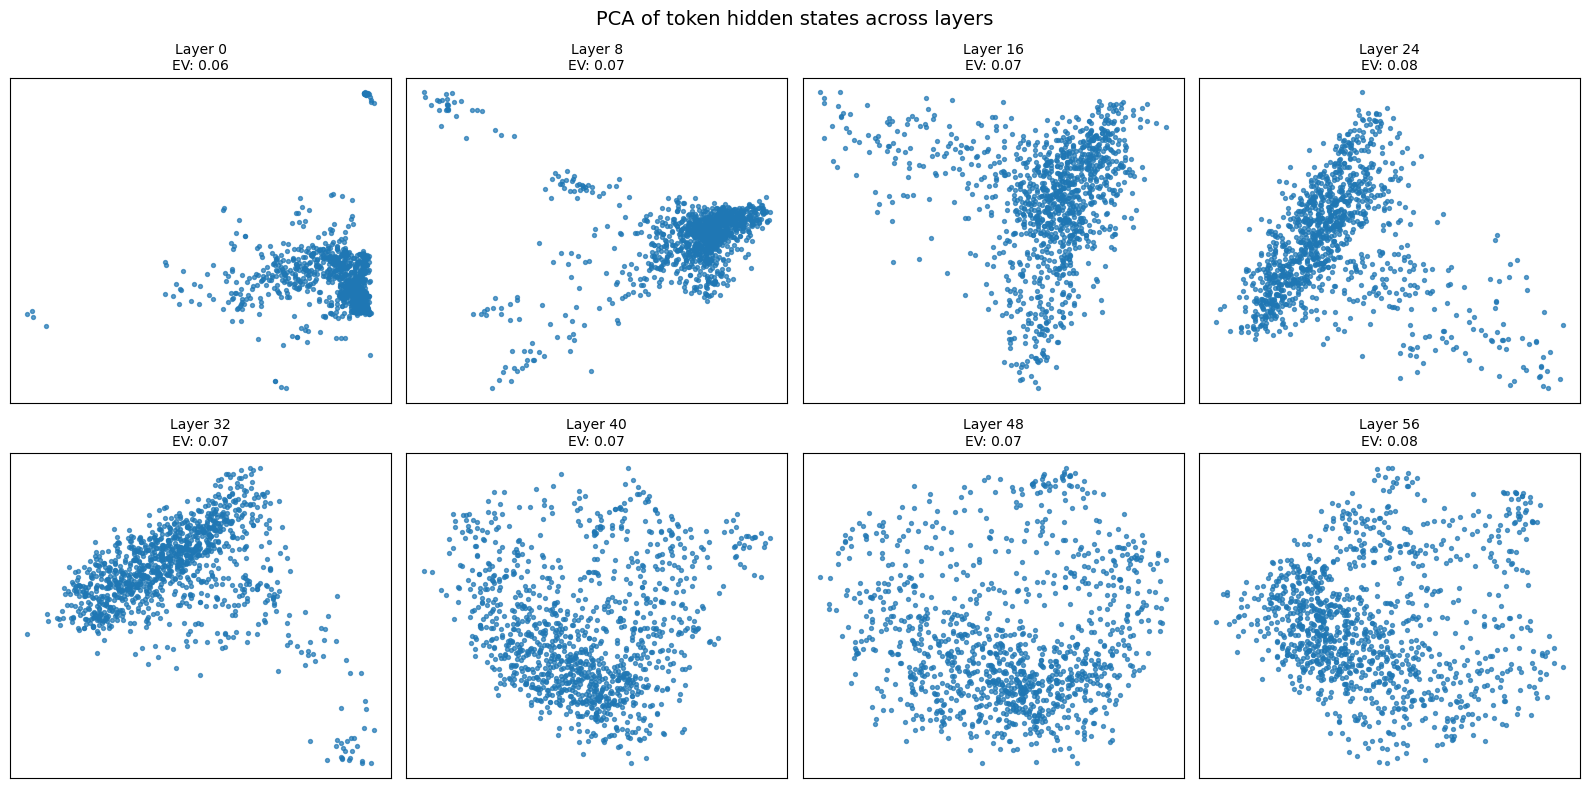

In [43]:
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

layers = sorted(saved_states.keys())

ncols = 4
nrows = math.ceil(len(layers) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = np.array(axes).reshape(-1)

all_speakers = sorted({span["speaker"] for span in turn_spans})
cmap = {sp: plt.cm.tab10(i % 10) for i, sp in enumerate(all_speakers)}

for ax, layer in zip(axes, layers):
    X_turn, turn_meta = pool_tokens_by_turn(saved_states[layer], offsets, turn_spans)

    pca = PCA(n_components=2)
    coords = pca.fit_transform(X_turn)

    colors = [cmap[m["speaker"]] for m in turn_meta]
    ax.scatter(coords[:, 0], coords[:, 1], c=colors, s=30, alpha=0.85)

    # Label each point by turn id so trajectory shifts are easy to inspect.
    for i, m in enumerate(turn_meta):
        ax.text(coords[i, 0], coords[i, 1], str(m["turn_id"]), fontsize=7)

    ax.set_title(
        f"Layer {layer}\nEV: {pca.explained_variance_ratio_.sum():.2f}",
        fontsize=10,
    )
    ax.set_xticks([])
    ax.set_yticks([])

for ax in axes[len(layers):]:
    ax.axis("off")

handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=cmap[sp],
                      markersize=7, label=sp) for sp in all_speakers]
fig.legend(handles=handles, loc="upper right", frameon=False, fontsize=8)

fig.suptitle("PCA of mean-pooled turn hidden states across layers", fontsize=14)
plt.tight_layout()
plt.show()

llm